# Point Spread Functions

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.special as sp
import scipy.integrate as integrate
import matplotlib.ticker as ticker


In [7]:
def getPSF_vec(R, Z, NA):
    n = 1
    halfAngle = np.asin(NA/n)
    a = np.linspace(0, halfAngle, 1000)

    # Setting up integrands
    grand0_real = sp.j0(R[..., None] * kPrime * np.sin(a)[None, None, :]) * np.sqrt(np.cos(a)[None, None, :]) * np.sin(a)[None, None, :] * (1 + np.cos(a)[None, None, :]) * np.cos(Z[..., None] * kPrime * np.cos(a)[None, None, :])
    grand0_im = sp.j0(R[..., None] * kPrime * np.sin(a)[None, None, :]) * np.sqrt(np.cos(a)[None, None, :]) * np.sin(a)[None, None, :] * (1 + np.cos(a)[None, None, :]) * np.sin(Z[..., None] * kPrime * np.cos(a)[None, None, :])

    grand1_real = sp.j1(R[..., None] * kPrime * np.sin(a)[None, None, :]) * np.sqrt(np.cos(a)[None, None, :]) * (np.sin(a)[None, None, :])**2 * np.cos(Z[..., None] * kPrime * np.cos(a)[None, None, :])
    grand1_im = sp.j1(R[..., None] * kPrime * np.sin(a)[None, None, :]) * np.sqrt(np.cos(a)[None, None, :]) * (np.sin(a)[None, None, :])**2 * np.sin(Z[..., None] * kPrime * np.cos(a)[None, None, :])

    grand2_real = sp.jv(2, R[..., None] * kPrime * np.sin(a)[None, None, :]) * np.sqrt(np.cos(a)[None, None, :]) * np.sin(a)[None, None, :] * (1 - np.cos(a)[None, None, :]) * np.cos(Z[..., None] * kPrime * np.cos(a)[None, None, :])
    grand2_im = sp.jv(2, R[..., None] * kPrime * np.sin(a)[None, None, :]) * np.sqrt(np.cos(a)[None, None, :]) * np.sin(a)[None, None, :] * (1 - np.cos(a)[None, None, :]) * np.sin(Z[..., None] * kPrime * np.cos(a)[None, None, :])

    # Now integrate across a on [0, halfAngle]
    gral0_real = np.trapezoid(grand0_real, axis = -1)
    gral0_im = np.trapezoid(grand0_im, axis = -1)
    I0 = gral0_real + complex(0, 1) * gral0_im

    gral1_real = np.trapezoid(grand1_real, axis = -1)
    gral1_im = np.trapezoid(grand1_im, axis = -1)
    I1 = gral1_real + complex(0, 1) * gral1_im

    gral2_real = np.trapezoid(grand2_real, axis = -1)
    gral2_im = np.trapezoid(grand2_im, axis = -1)
    I2 = gral2_real + complex(0, 1) * gral2_im

    # Combine for PSF
    PSF = np.abs(I0)**2 + 2 * np.abs(I1)**2 + np.abs(I2)**2
    return PSF

def getPSF(r, z, NA):
    n = 1
    halfAngle = np.asin(NA/n)
    a = np.linspace(0, halfAngle, 1000)

    # Setting up integrands
    # 500 rows for each r/z and 100 columns for each a in [0, halfAngle]
    grand0_real = sp.j0(r * kPrime * np.sin(a)) * np.sqrt(np.cos(a)) * np.sin(a) * (1 + np.cos(a)) * np.cos(z * kPrime * np.cos(a))
    grand0_im = sp.j0(r * kPrime * np.sin(a)) * np.sqrt(np.cos(a)) * np.sin(a) * (1 + np.cos(a)) * np.sin(z * kPrime * np.cos(a))

    grand1_real = sp.j1(r * kPrime * np.sin(a)) * np.sqrt(np.cos(a)) * np.sin(a)**2 * np.cos(z * kPrime * np.cos(a))
    grand1_im = sp.j1(r * kPrime * np.sin(a)) * np.sqrt(np.cos(a)) * np.sin(a)**2 * np.sin(z * kPrime * np.cos(a))

    grand2_real = sp.jv(2, r * kPrime * np.sin(a)) * np.sqrt(np.cos(a)) * np.sin(a) * (1 - np.cos(a)) * np.cos(z * kPrime * np.cos(a))
    grand2_im = sp.jv(2, r * kPrime * np.sin(a)) * np.sqrt(np.cos(a)) * np.sin(a) * (1 - np.cos(a)) * np.sin(z * kPrime * np.cos(a))

    # Now integrate across a on [0, halfAngle]
    gral0_real = np.trapezoid(grand0_real, x = a)
    gral0_im = np.trapezoid(grand0_im, x = a)
    I0 = gral0_real + complex(0, 1) * gral0_im

    gral1_real = np.trapezoid(grand1_real, x = a)
    gral1_im = np.trapezoid(grand1_im, x = a)
    I1 = gral1_real + complex(0, 1) * gral1_im

    gral2_real = np.trapezoid(grand2_real, x = a)
    gral2_im = np.trapezoid(grand2_im, x = a)
    I2 = gral2_real + complex(0, 1) * gral2_im

    # Combine for PSF
    PSF = np.abs(I0)**2 + 2 * np.abs(I1)**2 + np.abs(I2)**2
    return PSF

## Formatting

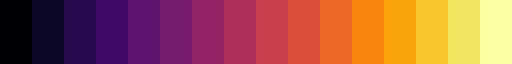

In [3]:
cm = 1 / 2.54
tickSize = 8
labelSize = 10
ms = 2

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern"
})

inferno = plt.colormaps['inferno'].resampled(16)
# cols = [inferno(1), inferno(2), inferno(3), inferno(4), inferno(5), inferno(6)]
# cols = ['#2B448C', "#FCA636FF", 'dodgerblue', "#ED5983"]
cols = [inferno(2), inferno(7), inferno(9), inferno(12), 'dodgerblue']

inferno 

## Parameters

In [5]:
# Setting parameters
wavelength = 1550 # nm
k = 2 * np.pi * 1/wavelength

NA = np.array([0.3, 0.55, 0.8]).reshape(-1, 1)
# NA = 0.55
# n = 1.517 # lens or free space?
n = 1
halfAngle = np.asin(NA/n)
kPrime = (2 * np.pi * n) / (wavelength)

# Cylindrical coordinates
r = (np.linspace(-6e3, 6e3, 500)).reshape(-1, 1)
z = (np.linspace(-30e3, 30e3, 500)).reshape(-1, 1)

# Reduced cylindrical coordinates
p = r * k * NA.T
u = z * k * (NA.T)**2 / n 

# Radial PSF
reducedRadialPSF = ((2 * sp.j1(p))/p)**2
radialPSF = ((2 * sp.j1(r * k * NA.T))/(r * k * NA.T))**2

# Axial PSF
reducedAxialPSF = (np.sin(u/4)/(u/4))**2
axialPSF = (np.sin((z * k * (NA.T)**2 / n)/4)/((z * k * (NA.T)**2 / n)/4))**2

### Comparison to Webb resolution

FWHM seems larger than aspproximate resolution from Webb. But I do remember there was an 0.8? factor somewhere.

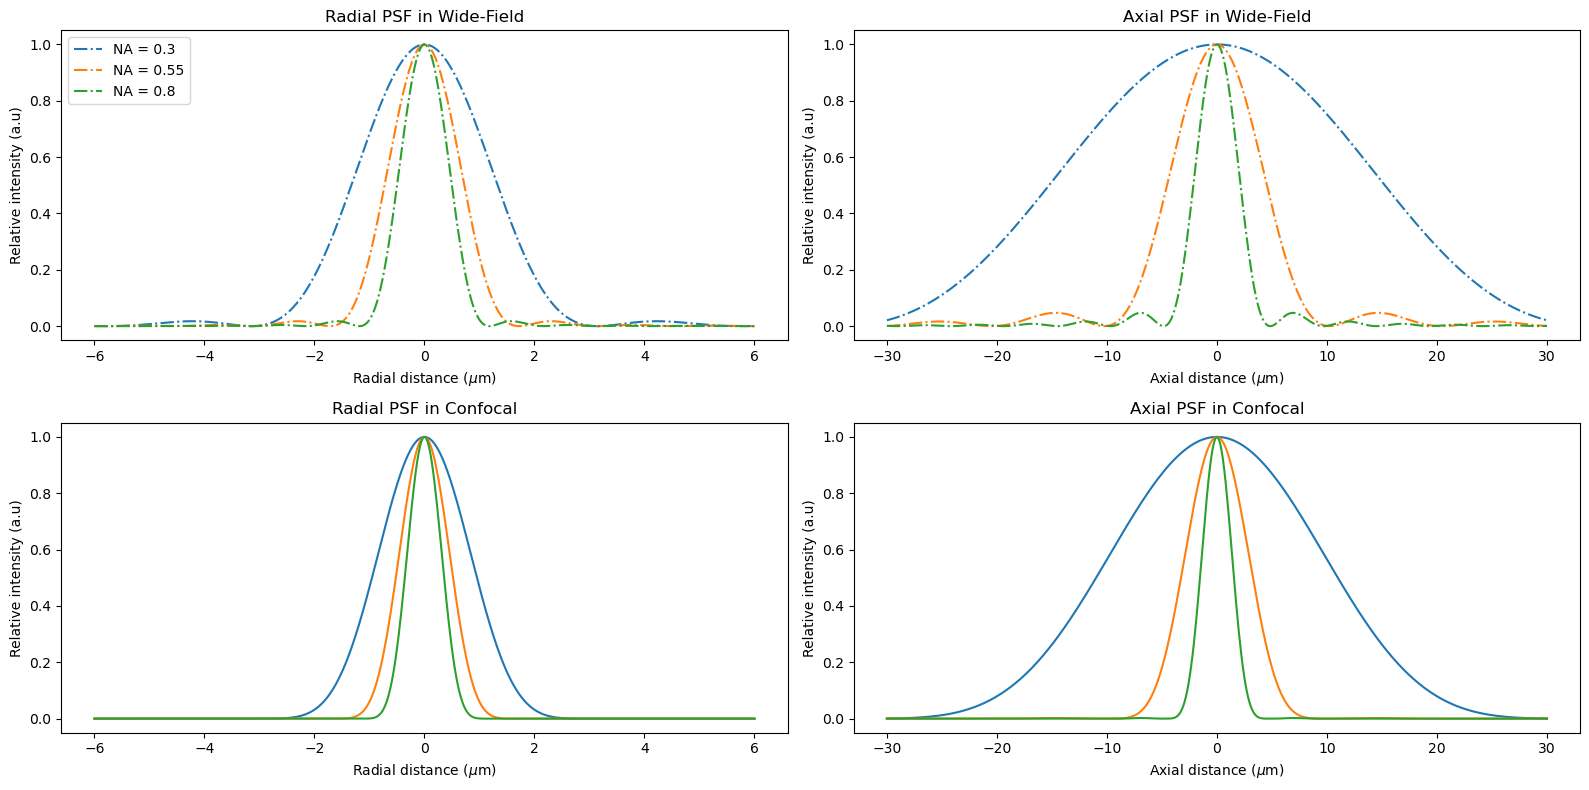

In [ ]:
# Should PSF be normalised to energy? 
fig, axs = plt.subplots(2, 2, figsize = (16, 8))

radialWide = axs[0, 0]
axialWide = axs[0, 1]
radialConf = axs[1, 0]
axialConf = axs[1, 1]

for i in range(np.shape(radialPSF)[1]):
    radialWide.plot(r/1e3, radialPSF[:, i], linestyle = '-.', label = fr'NA = {NA[i][0]}')
    radialConf.plot(r/1e3, radialPSF[:, i]**2, label = fr'NA = {NA[i][0]}')
    axialWide.plot(z/1e3, axialPSF[:, i], linestyle = '-.')
    axialConf.plot(z/1e3, axialPSF[:, i]**2)

radialWide.set_xlabel(r'Radial distance ($\mu$m)')
radialWide.set_ylabel(r'Relative intensity (a.u)')
radialWide.set_title('Radial PSF in Wide-Field')

radialConf.set_xlabel(r'Radial distance ($\mu$m)')
radialConf.set_ylabel(r'Relative intensity (a.u)')
radialConf.set_title('Radial PSF in Confocal')

axialWide.set_xlabel(r'Axial distance ($\mu$m)')
axialWide.set_ylabel(r'Relative intensity (a.u)')
axialWide.set_title('Axial PSF in Wide-Field')

axialConf.set_xlabel(r'Axial distance ($\mu$m)')
axialConf.set_ylabel(r'Relative intensity (a.u)')
axialConf.set_title('Axial PSF in Confocal')

radialWide.legend(loc = 'upper left')
plt.tight_layout()

plt.show()

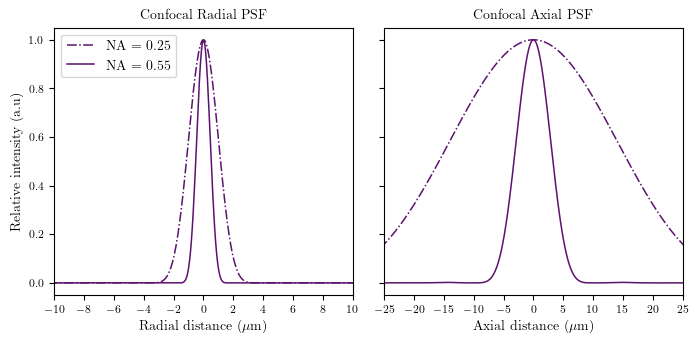

In [70]:
# Setting parameters
wavelength = 1550 # nm
k = 2 * np.pi * 1/wavelength
NA = np.array([0.25, 0.55]).reshape(-1, 1)
# NA = np.array([0.55]).reshape(-1, 1)
# n = 1.517 # lens or free space?
n = 1
halfAngle = np.asin(NA/n)

# Cylindrical coordinates
r = (np.linspace(-30e3, 30e3, 1000)).reshape(-1, 1)
z = (np.linspace(-30e3, 30e3, 1000)).reshape(-1, 1)

# Reduced cylindrical coordinates
p = r * k * NA.T
u = z * k * (NA.T)**2 / n 

# Radial PSF
reducedRadialPSF = ((2 * sp.j1(p))/p)**2
radialPSF = ((2 * sp.j1(r * k * NA.T))/(r * k * NA.T))**2

# Axial PSF
reducedAxialPSF = (np.sin(u/4)/(u/4))**2
axialPSF = (np.sin((z * k * (NA.T)**2 / n)/4)/((z * k * (NA.T)**2 / n)/4))**2

# Plot
fig, axs = plt.subplots(1, 2, figsize = (18 * cm, 9 * cm), sharey = True)
cols = [inferno(10), inferno(4), '#EB551A']
ls = ['-.', '-']

radial = axs[0]
axial = axs[1]

for i in range(np.shape(radialPSF)[1]):
        # # wide
        # radial.plot(r/1e3, radialPSF[:, i], 
        #                 c = cols[0], linestyle = ls[i], linewidth = 1.1,
        #                 label = fr'NA = {NA[i][0]}')
        # confocal
        radial.plot(r/1e3, radialPSF[:, i]**2, 
                        c = cols[1], linestyle = ls[i], linewidth = 1.1, 
                        label = fr'NA = {NA[i][0]}')
        
        # # wide
        # axial.plot(z/1e3, axialPSF[:, i], 
        #         c = cols[0], linestyle = ls[i], linewidth = 1.1,
        #                 label = fr'NA = {NA[i][0]}')
        # confocal
        axial.plot(z/1e3, axialPSF[:, i]**2, 
                c = cols[1], linestyle = ls[i], linewidth = 1.1,
                        label = fr'NA = {NA[i][0]}')

radial.set_xlabel(r'Radial distance ($\mu$m)', fontsize = labelSize)
radial.set_ylabel(r'Relative intensity (a.u)', fontsize = labelSize)
radial.set_title('Confocal Radial PSF', fontsize = labelSize)
radial.set_xlim([-10, 10])

axial.set_xlabel(r'Axial distance ($\mu$m)', fontsize = labelSize)
# axial.set_ylabel(r'Relative intensity (a.u)', fontsize = labelSize)
axial.set_title('Confocal Axial PSF ', fontsize = labelSize)
axial.set_xlim([-25, 25])

radial.legend(loc = 'upper left', fontsize = labelSize)
# axial.legend(loc = 'upper right', fontsize = labelSize)

radial.xaxis.set_major_locator(ticker.MultipleLocator(2))
axial.xaxis.set_major_locator(ticker.MultipleLocator(5))

radial.tick_params(axis = 'both', labelsize = tickSize)
axial.tick_params(axis = 'both', labelsize = tickSize)

plt.tight_layout()
plt.savefig(r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/confocal/NA psf.png',
                dpi = 300)
plt.show()

# Convolutions

In [8]:
from scipy import signal

In [124]:
# Calculate PSF for convolution
size = 200
r = (np.linspace(-30e3, 30e3, size))
z = (np.linspace(-30e3, 30e3, size))
R, Z = np.meshgrid(r.squeeze(), z.squeeze(), indexing = 'ij')
PSF_for_conv = getPSF_vec(R, Z, 0.55)

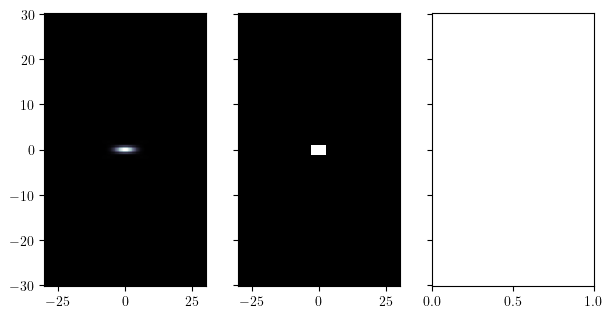

In [ ]:
implant = np.zeros((len(z), len(r)))
zImplant = [-3e3, 3e3]
rImplant = [-1e3, 1e3]

zStart = (abs(z - zImplant[0])).argmin()
zEnd = (abs(z - zImplant[1])).argmin()
rStart = (abs(r - rImplant[0])).argmin()
rEnd = (abs(r - rImplant[1])).argmin()

implant[rStart:rEnd, zStart:zEnd] = 1

fig, ax = plt.subplots(1, 3, figsize = (18 * cm, 9 * cm), sharey = True)

ax0 = ax[0]
# ax0.imshow((PSF_grid_vec)**2, cmap = 'bone', aspect = 'auto', norm = colors.PowerNorm(0.75))
ax0.pcolormesh(z/1e3, r/1e3, (PSF_for_conv)**2, cmap = 'bone')
# ax0.show_colorbar()

ax1 = ax[1]
ax1.pcolormesh(z/1e3, r/1e3, implant, cmap = 'bone')
# ax1.colorbar()

# ax2 = ax[2]
# ax2.pcolormesh(z/1e3, r/1e3, conv, cmap = 'bone')
# plt.show()

### Confocal

In [148]:
# Convolve!
# conv = signal.convolve2d(PSF_for_conv**2, implant, mode = 'same', boundary = 'fill')
conv = signal.convolve2d(PSF_for_conv, implant, mode = 'same', boundary = 'fill')
# # plt.imshow(conv)
# plt.show()

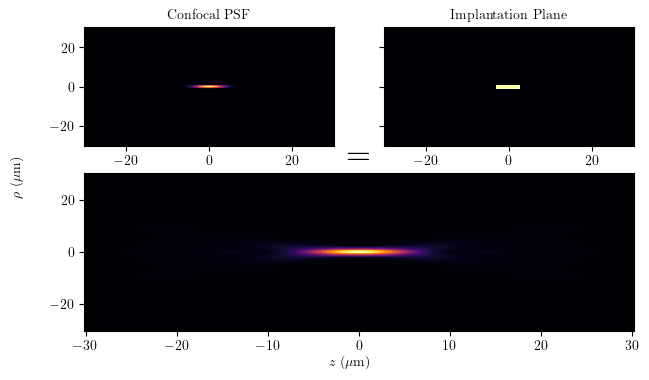

In [149]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize = (18 * cm, 10 * cm))
gs = fig.add_gridspec(
    2, 2,
    width_ratios = [1, 1], 
    height_ratios = [3, 4])

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, :])
ax1.set_yticklabels('')
# gs = GridSpec(2, 2, figure = fig)

# ax0 = fig.add_subplot(gs[0, 0])
# ax1 = fig.add_subplot(gs[0, 1])
# ax2 = fig.add_subplot(gs[1, :])

ax0.pcolormesh(z/1e3, r/1e3, (PSF_for_conv)**2, cmap = 'inferno')
# ax0.show_colorbar()
ax1.pcolormesh(z/1e3, r/1e3, implant, cmap = 'inferno')
# ax1.colorbar()
ax2.pcolormesh(z/1e3, r/1e3, conv, cmap = 'inferno')

ax0.set_title(fr'Confocal PSF', fontsize = labelSize)
ax1.set_title(fr'Implantation Plane', fontsize = labelSize)
ax2.set_title(fr'=', fontsize = 25)

fig.supxlabel(fr'$z$ ($\mu$m)', fontsize = labelSize)
fig.supylabel(fr'$\rho$ ($\mu$m)', fontsize = labelSize)

# plt.savefig(r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/confocal/convolution.png',
#                 dpi = 300)
plt.show()


### Wide Field

In [121]:
# Convolve!
conv_WF = signal.convolve2d(PSF_for_conv, implant, mode = 'same', boundary = 'fill')
# plt.pcolormesh(z/1e3, r/1e3, conv, cmap = 'bone')
# # plt.imshow(conv)
# plt.show()

TypeError: Incompatible X, Y inputs to pcolormesh; see help(pcolormesh)

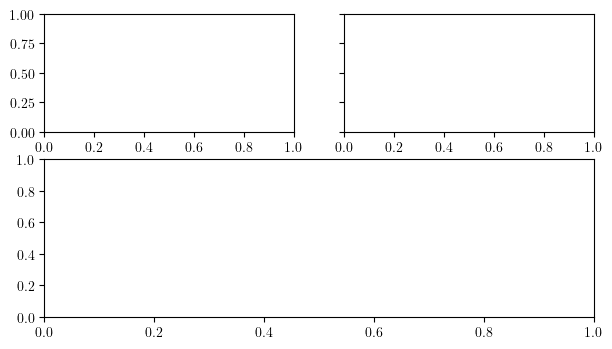

In [122]:
fig = plt.figure(figsize = (18 * cm, 10 * cm))
gs = fig.add_gridspec(
    2, 2,
    width_ratios = [1, 1], 
    height_ratios = [3, 4])

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, :])
ax1.set_yticklabels('')

ax0.pcolormesh(z/1e3, r/1e3, (PSF_for_conv), cmap = 'inferno')
ax1.pcolormesh(z/1e3, r/1e3, implant, cmap = 'inferno')
ax2.pcolormesh(z/1e3, r/1e3, conv_WF, cmap = 'inferno')

ax0.set_title('Confocal PSF')
ax1.set_title('Implantation Plane')
plt.show()

### Random

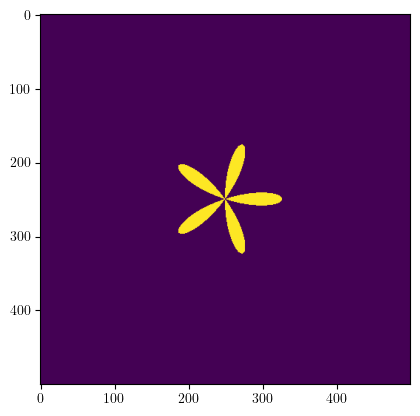

In [119]:
# Create a grid of coordinates
size = 500
x = np.linspace(-1, 1, size)
y = np.linspace(-1, 1, size)
X, Y = np.linspace(-1, 1, size), np.linspace(-1, 1, size)

# Generate a 2D star mask (using distance from center)
xv, yv = np.meshgrid(x, y)
r = np.sqrt(xv**2 + yv**2)

# Modulate radius with a cosine wave to create points (5-pointed star)
theta = np.arctan2(yv, xv)
star_mask = r < 0.01 + 0.3 * np.cos(5 * theta)

# plt.pcolormesh(z/1e3, r/1e3, star_mask, cmap = 'inferno')
plt.imshow(star_mask, cmap = 'viridis')
plt.show()

In [ ]:
fig = plt.figure(figsize = (18 * cm, 10 * cm))
gs = fig.add_gridspec(
    2, 2,
    width_ratios = [1, 1], 
    height_ratios = [3, 4])

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, :])
ax1.set_yticklabels('')

ax0.pcolormesh(z/1e3, r/1e3, (PSF_for_conv), cmap = 'inferno')

ax1.pcolormesh(z/1e3, r/1e3, implant, cmap = 'inferno')

ax2.pcolormesh(z/1e3, r/1e3, conv_WF, cmap = 'inferno')
plt.show()

# Recreating 3D plots from Webb

In [1]:
import scipy.integrate as integrate
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

In [9]:
# Setting parameters
wavelength = 1550 # nm
n = 1
k = 2 * np.pi * 1/(wavelength)
kPrime = (2 * np.pi * n) / (wavelength)
NA = 0.55
halfAngle = np.asin(NA/n)

# Cylindrical coordinates
r = np.linspace(-10e3, 10e3, 500)
z = np.linspace(-25e3, 25e3, 750)

In [11]:
# Non-vectorised PSF calculation
# DO NOT RERUN THIS CELL !! 
PSF_grid = np.zeros([len(r), len(z)])
for i, zValue in enumerate(z):
    for j, rValue in enumerate(r):
        PSF_grid[i, j] = getPSF(rValue, zValue, 0.55)

IndexError: index 500 is out of bounds for axis 0 with size 500

In [38]:
# Vectorise the nested for loop
R, Z = np.meshgrid(r.squeeze(), z.squeeze(), indexing = 'ij')
PSF_grid_vec = getPSF_vec(R, Z, 0.55)

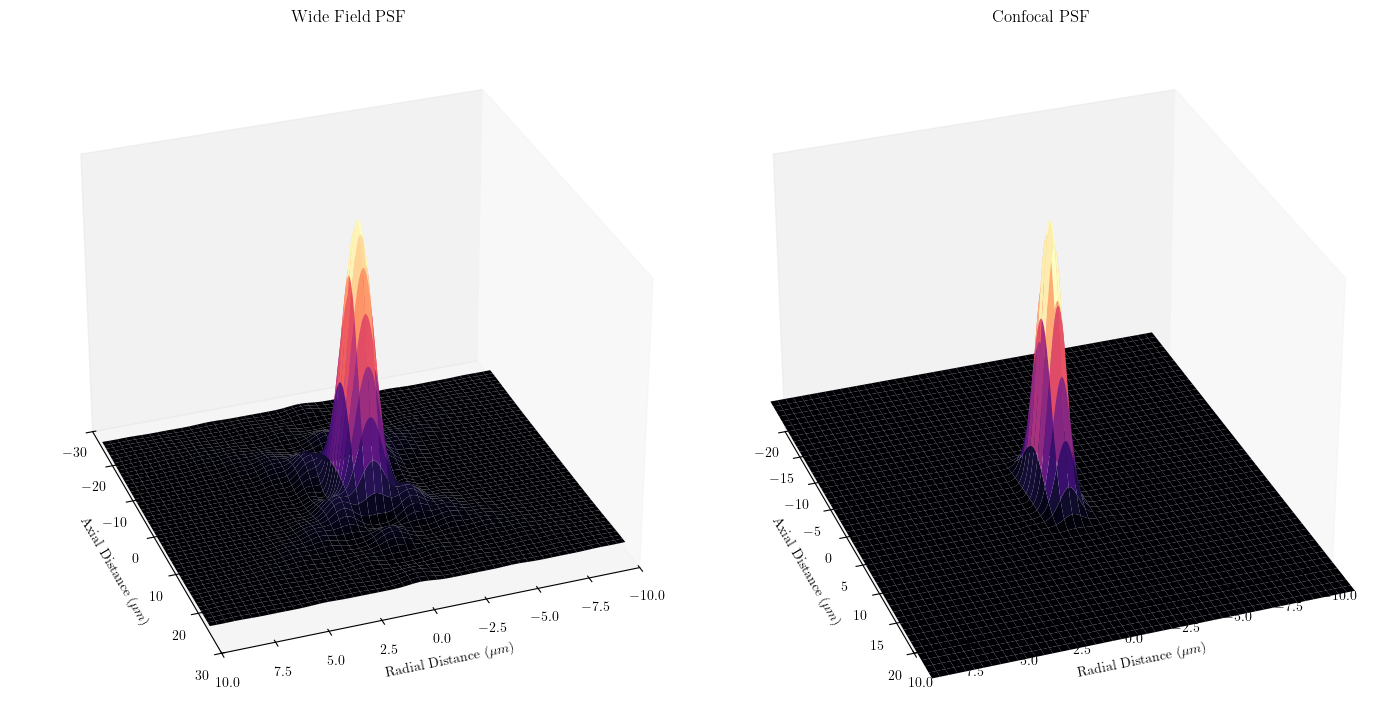

In [ ]:
# Now plot with meshgrid !
fig, ax = plt.subplots(1, 2,
                    figsize = (14, 8), 
                    subplot_kw = {"projection": "3d"})

wide = ax[0]
conf = ax[1]

wide.view_init(elev = 30, azim = 70) 
wide.grid(False)
wide.set_xlim([-10, 10])
wide.set_ylim([-30, 30])
wide.zaxis.set_label_position('none')
wide.zaxis.set_ticks_position('none')
wide.plot_surface(R/1e3, Z/1e3, PSF_grid_vec, cmap = 'magma',
                    linewidth = 0, antialiased = True)
wide.set_xlabel(fr'Radial Distance ($\mu m$)')
wide.set_ylabel(fr'Axial Distance ($\mu m$)')
wide.set_title('Wide Field PSF')

conf.view_init(elev = 30, azim = 70) 
conf.grid(False)
conf.set_xlim([-10, 10])
conf.set_ylim([-20, 20])
conf.zaxis.set_label_position('none')
conf.zaxis.set_ticks_position('none')
conf.plot_surface(R/1e3, Z/1e3, PSF_grid_vec**2, cmap = 'magma',
                    linewidth = 0, antialiased = True)
conf.set_xlabel(fr'Radial Distance ($\mu m$)')
conf.set_ylabel(fr'Axial Distance ($\mu m$)')
conf.set_title('Confocal PSF')

plt.tight_layout()
plt.show()

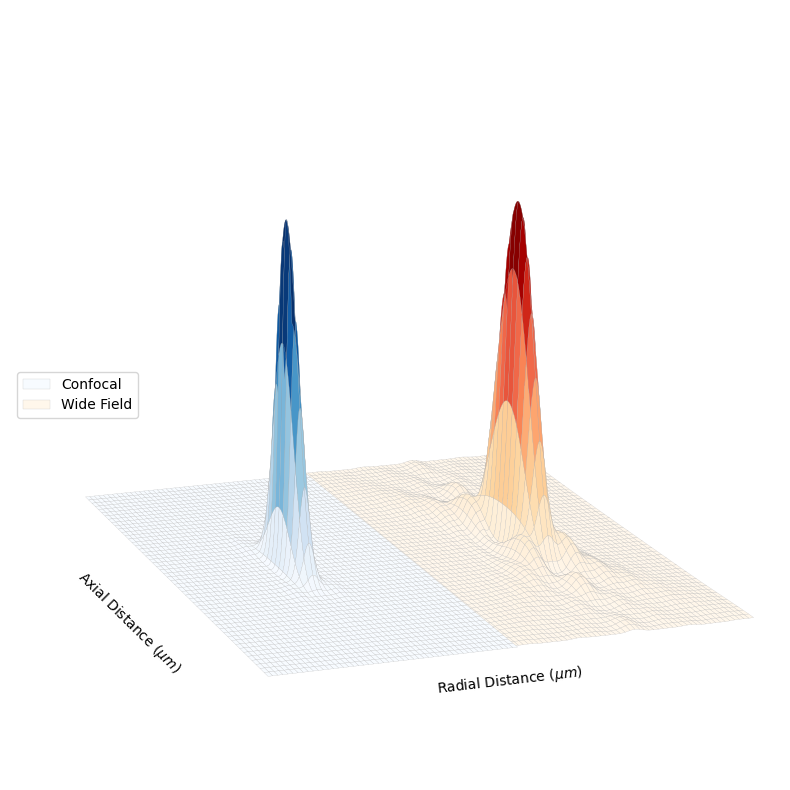

In [13]:
# Now plot with meshgrid !
fig, ax = plt.subplots(figsize = (8, 8), 
                       subplot_kw = {"projection": "3d"})
ax.view_init(elev = 15, azim = 70) 
ax.grid(False)
ax.xaxis.set_pane_color((0.0, 0.0, 0.0, 0.0))
ax.yaxis.set_pane_color((0.0, 0.0, 0.0, 0.0))
ax.zaxis.set_pane_color((0.0, 0.0, 0.0, 0.0))

# Normalised plots
ax.plot_surface((R)/1e3, Z/1e3, (PSF_grid_vec**2)/np.max(PSF_grid_vec**2),
                edgecolor = '0.7', 
                linewidth = 0.15,
                cmap = 'Blues',
                antialiased = True, 
                label = 'Confocal')

ax.plot_surface((R - 19.7e3)/1e3, Z/1e3, PSF_grid_vec/np.max(PSF_grid_vec),
                edgecolor = '0.7',
                linewidth = 0.15, 
                cmap = 'OrRd',
                antialiased = True, 
                label = 'Wide Field')

# Housekeeping
ax.set_xlim([-30, 10])
ax.set_xticks([])
ax.set_xlabel(fr'Radial Distance ($\mu m$)')
ax.set_ylim([-20, 20]) 
ax.set_yticks([])
ax.set_ylabel(fr'Axial Distance ($\mu m$)')
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
ax.zaxis.set_label_position('none')
ax.zaxis.set_ticks_position('none')

plt.legend(loc = 'center left')
plt.tight_layout()
plt.show()

In [6]:
import matplotlib.colors as colors

cm = 1/2.54
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern"
})

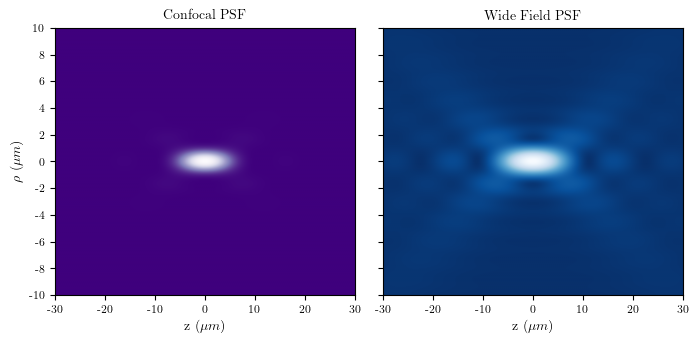

In [ ]:
# fig = plt.figure(figsize = (12, 6))
# gs = fig.add_gridspec(1, 2)
# CF = fig.add_subplot(gs[0, 0]) 
# WF = fig.add_subplot(gs[0, 1], sharey = CF)
fig, ax = plt.subplots(1, 2, figsize = (18 * cm, 9 * cm), sharey = True)

CF = ax[1]
# CF.imshow(2*np.log(PSF_grid_vec.T), cmap = 'magma')
CF.imshow((PSF_grid_vec)**2, cmap = 'Purples_r', aspect = 'auto', norm = colors.PowerNorm(0.75))
CF.set_yticks(np.linspace(0, 500, len(np.arange(10, -11, -2))))
CF.set_yticklabels(np.arange(10, -11, -2), fontsize = tickSize)
CF.set_ylabel(fr'$\rho$ ($\mu m$)', fontsize = labelSize)
CF.set_xticks(np.linspace(0, 750, len(np.arange(-30, 31, 10))))
CF.set_xticklabels(np.arange(-30, 31, 10), fontsize = tickSize)
CF.set_xlabel(fr'z ($\mu m$)', fontsize = labelSize)
CF.set_title('Confocal PSF', fontsize = labelSize)

WF = ax[0]
# WF.imshow(np.log(PSF_grid_vec.T), cmap = 'magma')
WF.imshow(PSF_grid_vec, cmap = 'Blues_r', aspect = 'auto', norm = colors.PowerNorm(0.75))
WF.set_yticks(np.linspace(0, 500, len(np.arange(10, -11, -2))))
WF.set_yticklabels(np.arange(10, -11, -2), fontsize = tickSize)
# WF.set_xticks(np.linspace(0, 750, len(np.arange(-30, 31, 5))))
WF.set_xticks(np.linspace(0, 750, len(np.arange(-30, 31, 10))))
WF.set_xticklabels(np.arange(-30, 31, 10), fontsize = tickSize)
WF.set_xlabel(fr'z ($\mu m$)', fontsize = labelSize)
WF.set_title(fr'Excitation PSF ', fontsize = labelSize)

plt.tight_layout()
plt.savefig(r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/confocal/3D PSF.png',
                dpi = 300)
plt.show()

# Calculations

In [10]:
wavelength = 1550 # nm
n_caf = 1.43
n_sic = 2.6
a = 5.451e-10
b = a
c = a

print('RADIAL RESOLUTION')
r_radial_vac = (0.44 * wavelength / 0.55)/1e9
print(r_radial_vac)

print('AXIAL RESOLUTION')
r_axial_vac = (0.76 * wavelength/(n - np.sqrt(n**2 - 0.55**2)))/1e9
print(r_axial_vac)

print('CROSS SECTION')
# cross_section = np.pi * ((r_radial_vac)/2)**2 # defined wrt. radius
cross_section = np.pi * ((r_radial_vac))**2 # defined wrt. diameter
print(f'{cross_section} m^2')

print('CYLINDRICAL VOLUME')
thickness_caf = 1e-6 # m, approximately
cyl_vol_caf = cross_section * thickness_caf
print(fr'{cyl_vol_caf} m^3') #in m^-3

unitVolume = a * b * c
print('UNIT CELLS IN ADDRESSED VOLUME')
cellsTotal = cyl_vol_caf / unitVolume
print(fr'{cellsTotal}') #in m^-3

print('TOTAL IONS')
fluence_caf =  1.5e13 * 1e4 # m^-2
addressed_caf = fluence_caf * cross_section
print(f'{np.floor(addressed_caf)} ions')

print('IONS PER UNIT CELL')
print(f'{addressed_caf / cellsTotal}')

RADIAL RESOLUTION
1.24e-06
AXIAL RESOLUTION
7.146525497229967e-06
CROSS SECTION
4.830512864159666e-12 m^2
CYLINDRICAL VOLUME
4.830512864159666e-18 m^3
UNIT CELLS IN ADDRESSED VOLUME
29823918023.355564
TOTAL IONS
724576.0 ions
IONS PER UNIT CELL
2.429516232765e-05


In [ ]:
# Rabi Estimate
pInput = 10e-6 # assume 10uW excitation
# IInput = pInput/cyl_vol_caf # W/m^3
IInput = pInput/cross_section # W/m^2
muG1 = 1.53e-32 # from Tim's thesis
h = 6.62607015e-34 
c = 299792458 
eps0 = 8.8541878188e-12
hbar = h / (2 * np.pi)

rabi0 = muG1 / hbar * np.sqrt(2 * IInput /(c * n_caf * eps0))

print(f'RABI FREQUENCY: {rabi0/(1e6 * 2 * np.pi):3f} MHz') # angular frequency
print(f'PI/2 PULSE TIME: {np.pi/rabi0 * 1e6:.3f} us') 